In [2]:
OBJECT_NAMES  = ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 
                 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 
                 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 
                 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 
                 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 
                 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 
                 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 
                 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cellone', 'microwave', 'oven', 
                 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 
                 'toothbrush']

tensor([[141.4570, 499.9815, 284.2219, 636.1990],
        [  2.6402, 456.5424, 151.4151, 556.4644],
        [484.4787, 558.5721, 625.8516, 640.0000],
        [488.2045, 394.2385, 605.1906, 530.3768],
        [489.1489, 397.4522, 603.3052, 528.6087]]) tensor([0.7451, 0.7205, 0.4165, 0.3717, 0.3264]) tensor([3, 3, 3, 6, 8])


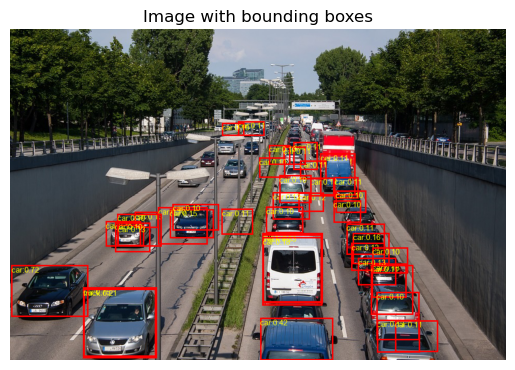

In [11]:
import torch, torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights

from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as T

import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline



weights = SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
model = ssdlite320_mobilenet_v3_large(weights=weights)
model.eval()

pre = weights.transforms()

# transform ảnh theo chuẩn weight
preprocess = weights.transforms()
try:
    font = ImageFont.truetype("arial.ttf", 15)
except IOError:
    font = ImageFont.load_default()

img_path = "D:/Teach_n_Train/Advanced_Lessons_CV/LABS/r-cnn/faster-rcnn/traffic.jpg"
filename = os.path.basename(img_path)

img = Image.open(img_path).convert('RGB')
x = pre(img).unsqueeze(0)

with torch.no_grad():
    out = model(x)[0]   # dict: 'boxes','scores','labels'

print(out['boxes'][:5], out['scores'][:5], out['labels'][:5])

boxes = out["boxes"].cpu().numpy()
labels = out["labels"].cpu().numpy()
scores = out["scores"].cpu().numpy()

draw = img.copy()
d = ImageDraw.Draw(draw)
for b,l,s in zip(boxes, labels, scores):
    if s < 0.1: continue
    x1,y1,x2,y2 = b
    d.rectangle([x1,y1,x2,y2], outline=(255,0,0), width=3)
    d.text((x1,y1), f"{OBJECT_NAMES[int(l)]}:{s:.2f}", font = font, fill=(255,255,0))

output_path = "D:/Teach_n_Train/Advanced_Lessons_CV/LABS/Object_Detection/Lab04/outputs"
os.makedirs(output_path, exist_ok=True)

draw.save(output_path + "/torch_infer_SSD_" + filename)

plt.imshow(np.asarray(draw))
plt.title("Image with bounding boxes")
plt.axis('off')
plt.show()